<a href="https://colab.research.google.com/github/FrancisQL/Computer_Vision/blob/main/Notebooks/AL02-Filtering/AL2_Convolution_Filtering1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/andrewgodbout/MCS-3950-F26/blob/main/Notebooks/AL02-Filtering/AL2_Convolution_Filtering1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AL2 — Convolution and Filtering Lab
**MCS 3950 Computer Vision**

Work through the three parts in order. Each part has a **task** you implement
and a **checkpoint question** you answer in the provided cell.

| Part | Topic | Time |
|------|-------|------|
| 1 | Design kernels from first principles | ~10 min |
| 2 | Denoising benchmark — what the metric misses | ~5 min |
| 3 | Preprocessing real PEI aerial imagery | ~25 min |
| ★ | Bonus: mystery kernel challenge | if time |

> Writing a convolution loop by hand is covered in the **L3 follow-along
> notebook**, section 1 — worth running if you want to see the mechanics.

> **Not submitted or graded.** The goal is hands-on practice before Test 1.


## Setup — run this first


cam    shape: (512, 512)   dtype: uint8
coins  shape: (303, 384)  dtype: uint8
chelsea shape: (300, 451)  dtype: uint8
Setup complete.


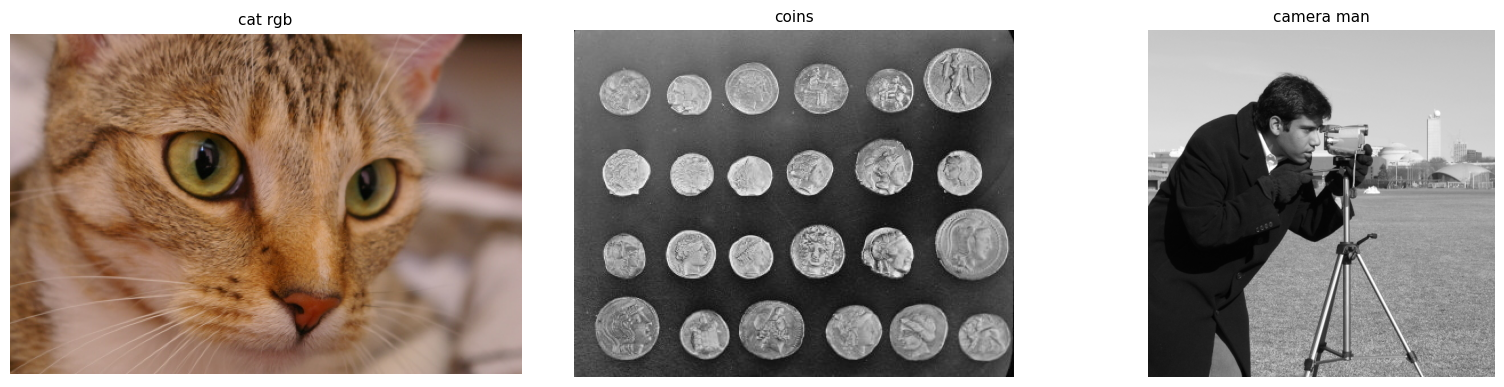

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data as skdata

plt.rcParams.update({"figure.dpi":100, "axes.spines.top":False,
                     "axes.spines.right":False, "font.size":11})

# ── Images used throughout this lab ──────────────────────────────────────────
# Cameraman: classic grayscale benchmark, 512×512
cam  = skdata.camera()

# Coins: has both flat regions and curved edges — good for filter comparison
coins = skdata.coins()

# Chelsea (cat): RGB — used in Part 2 bilateral demo
chelsea_rgb = skdata.chelsea()
chelsea     = cv2.cvtColor(chelsea_rgb[:,:,::-1], cv2.COLOR_BGR2GRAY)

print(f"cam    shape: {cam.shape}   dtype: {cam.dtype}")
print(f"coins  shape: {coins.shape}  dtype: {coins.dtype}")
print(f"chelsea shape: {chelsea.shape}  dtype: {chelsea.dtype}")

# ── Helper: Peak Signal-to-Noise Ratio (higher = better reconstruction) ──────
def psnr(clean, filtered):
    """PSNR in dB. Higher = filtered image is closer to the clean original."""
    mse = np.mean((clean.astype(float) - filtered.astype(float))**2)
    return 20 * np.log10(255.0 / np.sqrt(mse)) if mse > 0 else float('inf')

# ── Helper: show a row of images ─────────────────────────────────────────────
def show(images, titles, cmap='gray', vmin=0, vmax=255, figw=16):
    fig, axes = plt.subplots(1, len(images), figsize=(figw, 4))
    if len(images) == 1:
        axes = [axes]
    for ax, im, t in zip(axes, images, titles):
        ax.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(t, fontsize=11)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print("Setup complete.")

show([chelsea_rgb, coins, cam], ["cat rgb", "coins", "camera man"] )


---
## Part 1 — Design Kernels from First Principles  `⏱ ~10 min`


Fill in the `???` values in each kernel below. Use the **rule of thumb**:

- Weights that sum to **1** → preserve overall brightness (blur/pass-through).
- Weights that sum to **0** → output is zero in flat regions, non-zero at edges.
- A **positive centre, negative surround** → sharpening / edge enhancement.

Don't run the verification cell until you've filled them all in — try to reason
from the kernel weights first.


In [3]:
# ── Task: replace each 0.0 placeholder with the correct value ─────────────────
# Read the comment above each kernel carefully before filling in.

# Kernel A — 3×3 uniform blur (all weights equal, sum to 1)
# Hint: 9 cells, total sum = 1, so each cell = ?
kernel_A = np.array([
    [0.11, 0.11, 0.11],   # FILL IN
    [0.11, 0.12, 0.11],   # FILL IN
    [0.11, 0.11, 0.11],   # FILL IN
], dtype=np.float32)

# Kernel B — sharpen (centre = 5, 4 direct neighbours are negative; total sum = 1)
# Hint: 0 + neighbour + 0 + neighbour + 5 + neighbour + 0 + neighbour + 0 = 1
#       so 4 × neighbour = 1 − 5 = −4, so each neighbour = ?
kernel_B = np.array([
    [ 0,  -1,  0],   # FILL IN the 0.0
    [-1,  5,  -1],  # FILL IN the 0.0s
    [ 0,  -1,  0],   # FILL IN the 0.0
], dtype=np.float32)

# Kernel C — detect horizontal edges (positive top row, negative bottom row)
# Hint: the bottom row is the negative of the top row (so the total sum = 0)
kernel_C = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1],  # FILL IN
], dtype=np.float32)

# Kernel D — motion blur: smear horizontally across 7 pixels (sum = 1)
# Hint: put non-zero weights only in the MIDDLE row of a 7×7 kernel.
kernel_D = np.zeros((7, 7), dtype=np.float32)
# FILL IN: kernel_D[row_index, :] = weight_per_cell (i.e., change the below ? to the correct row and uncomment the line)
kernel_D[1, :] = [0.14, 0.14, 0.14, 0.16, 0.14, 0.14, 0.14]


  Kernel A (Blur                )  sum = +1.000  ✓
  Kernel B (Sharpen             )  sum = +1.000  ✓
  Kernel C (Horizontal edges    )  sum = +0.000  ✓
  Kernel D (Motion blur         )  sum = +1.000  ✓


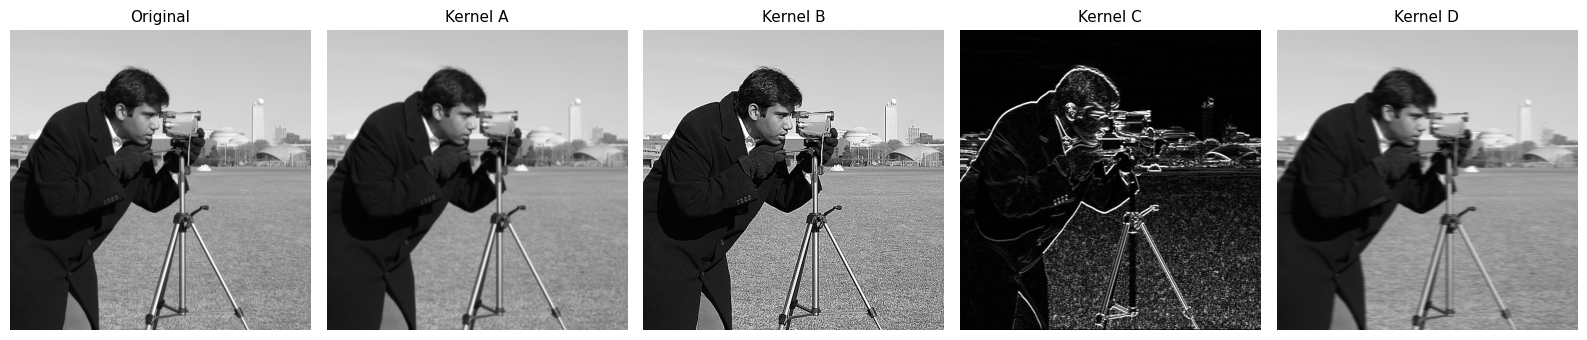

In [4]:
# ── Verification and visualization ───────────────────────────────────────────
# Replace the ??? first! This cell will error until you do.

try:
    results = {}
    expected_sums = {"A": 1.0, "B": 1.0, "C": 0.0, "D": 1.0}

    for label, k, desc in [
        ("A", kernel_A, "Blur"),
        ("B", kernel_B, "Sharpen"),
        ("C", kernel_C, "Horizontal edges"),
        ("D", kernel_D, "Motion blur"),
    ]:
        s = k.sum()
        ok = abs(s - expected_sums[label]) < 0.01
        flag = "✓" if ok else f"✗ (sum={s:.3f}, expected {expected_sums[label]})"
        print(f"  Kernel {label} ({desc:20s})  sum = {s:+.3f}  {flag}")
        raw = cv2.filter2D(cam, cv2.CV_32F, k)
        # For edge kernels (sum≈0), show absolute value; otherwise clip
        if abs(s) < 0.1:
            display = np.clip(np.abs(raw), 0, 255).astype(np.uint8)
        else:
            display = np.clip(raw, 0, 255).astype(np.uint8)
        results[label] = display

    show([cam] + list(results.values()),
         ["Original"] + [f"Kernel {l}" for l in results])

except NameError as e:
    print(f"Fill in the ??? values first: {e}")


### Checkpoint 1

**Q1a.** Kernel C (horizontal edge detector) has weights that sum to 0.
What does this mean for a completely flat region of the image?
What does it mean for a bright-to-dark edge?

In a completely flat region of an image, a weight summing up to 0 means there will be no change (in this case, all pixels will become black (0) as there is no change in color), that is why images that present no change of color in certain regions get those regions painted black, because the change in color (measured from black to white) gets a value of 0.

---

**Q1b.** The motion blur kernel (D) smears in one direction. How would you
modify it to produce a **diagonal** motion blur instead?

Instead of making the values in a row sum up to 1, I would change the values so that a diagonal (of the direction I want the motion blur to be in) gets values that sum to 0, making sure all other values stay 0.0 so they don't make interference.


---
## Part 2 — Denoising Benchmark  `⏱ ~5 min`


We add Gaussian noise at two levels and compare three filters. The filter calls
are **pre-written** — run them, then read the **PSNR table** and the edge profile.
The checkpoint questions are the point of this section.

**PSNR** (Peak signal-to-noise Ratio) measures the ratio between maximum possible power of a signal and the power of a corrupting noise. It quantifies the quality difference between an original and a degraded version. Higher PSNR ratios *generally* indicate higher quality. We say generally here because it is a global metric that will not take into account edges or local areas that may contribute more greatly to image understanding and perceived quality.


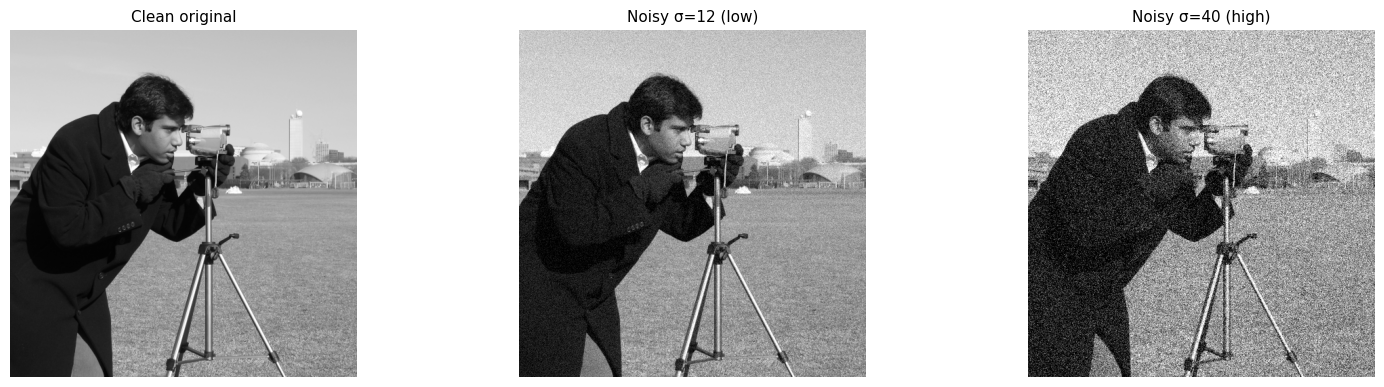

PSNR of noisy_lo: 26.7 dB
PSNR of noisy_hi: 16.9 dB


In [5]:
# ── Pre-written: add noise at two levels ─────────────────────────────────────
rng = np.random.default_rng(0)

def add_noise(img, sigma):
    noise = rng.normal(0, sigma, img.shape)
    return np.clip(img.astype(float) + noise, 0, 255).astype(np.uint8)

noisy_lo = add_noise(cam, sigma=12)   # low noise
noisy_hi = add_noise(cam, sigma=40)   # high noise

show([cam, noisy_lo, noisy_hi],
     ["Clean original", "Noisy σ=12 (low)", "Noisy σ=40 (high)"])
print(f"PSNR of noisy_lo: {psnr(cam, noisy_lo):.1f} dB")
print(f"PSNR of noisy_hi: {psnr(cam, noisy_hi):.1f} dB")


In [37]:
# ── Pre-written: the three filters ───────────────────────────────────────────
# You designed kernels by hand in Part 1. Here the filter calls are given, so
# the time goes into reading the results rather than retyping OpenCV calls.

def apply_all_filters(noisy_img):
    """
    Apply three denoising filters to noisy_img and return a dict of results.

    Returns
    -------
    dict with keys: 'box', 'gaussian', 'bilateral'
    Each value is a uint8 array, same shape as noisy_img.
    """
    return {
        # 5x5 box: cv2.blur takes the image and a (width, height) kernel size
        'box':       cv2.blur(noisy_img, (5, 5)),

        # sigma = 2. With ksize=(0,0) OpenCV infers the kernel size from sigmaX,
        # and sigmaY is set equal to sigmaX when it is not given.
        'gaussian':  cv2.GaussianBlur(noisy_img, (0, 0), 2),

        # d = neighbourhood diameter; sigmaColor gates by intensity difference,
        # sigmaSpace by distance. Note these are NOT retuned per noise level.
        'bilateral': cv2.bilateralFilter(noisy_img, 9, sigmaSpace=60, sigmaColor=20),
    }


Filter            σ=12 PSNR     σ=40 PSNR
------------------------------------------
Noisy input           26.7         16.9
  box                 26.5         24.8
  gaussian            25.8         24.7
  bilateral           31.6         18.4


Low noise results


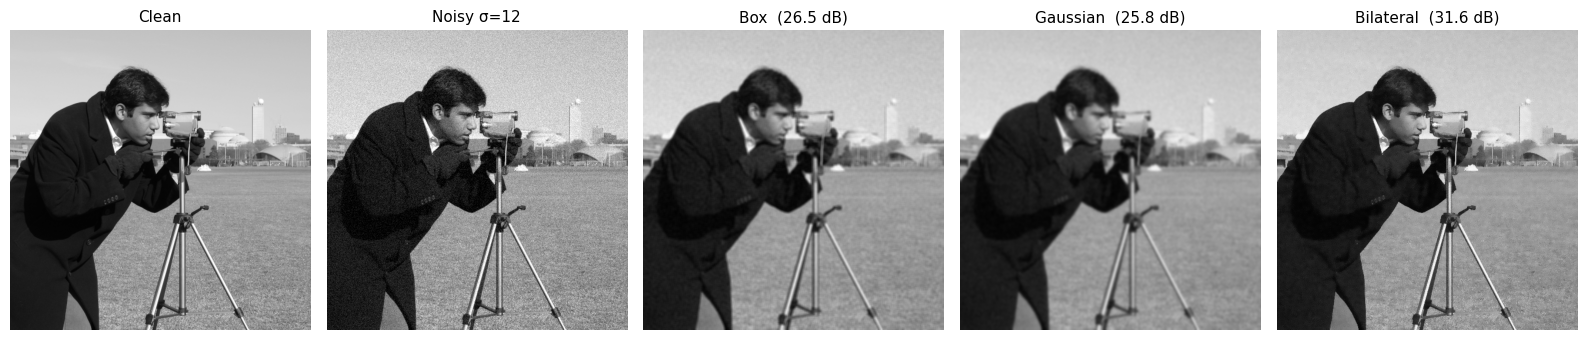



High noise results


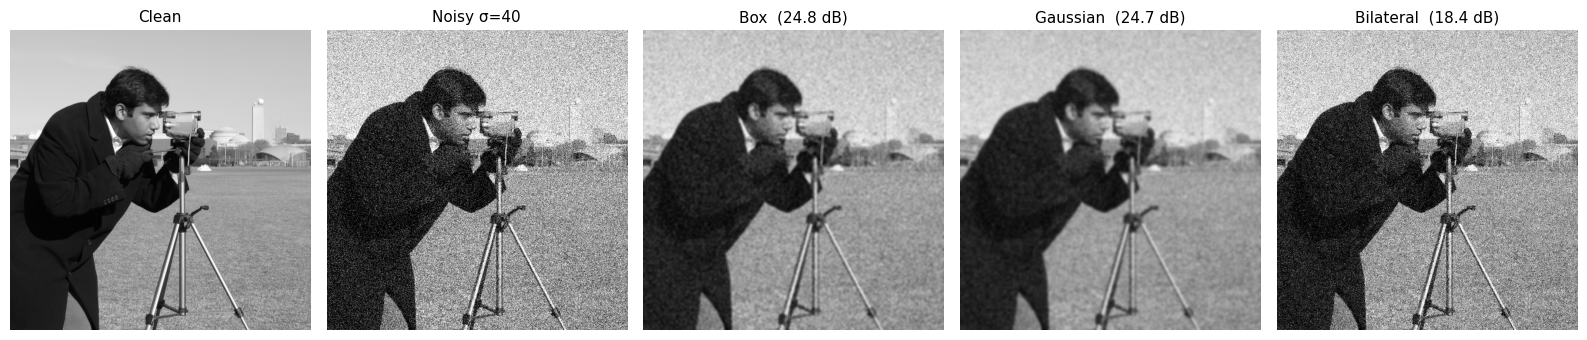

In [38]:
# ── PSNR table — runs once your filters are filled in ────────────────────────
try:
    lo_results = apply_all_filters(noisy_lo)
    hi_results = apply_all_filters(noisy_hi)

    if any(v is None for v in lo_results.values()):
        missing = [k for k,v in lo_results.items() if v is None]
        raise ValueError(f"Still None: {missing}. Replace the None placeholders.")

    print(f"{'Filter':<14} {'σ=12 PSNR':>12}  {'σ=40 PSNR':>12}")
    print("-" * 42)
    print(f"{'Noisy input':<14} {psnr(cam, noisy_lo):>11.1f}  {psnr(cam, noisy_hi):>11.1f}")
    for name in ['box', 'gaussian', 'bilateral']:
        lo_p = psnr(cam, lo_results[name])
        hi_p = psnr(cam, hi_results[name])
        print(f"  {name:<12} {lo_p:>11.1f}  {hi_p:>11.1f}")

    print("\n\nLow noise results")

    #visual lo noise
    show([cam, noisy_lo,
      lo_results['box'], lo_results['gaussian'], lo_results['bilateral']],
      ["Clean", "Noisy σ=12",
      f"Box  ({psnr(cam, lo_results['box']):.1f} dB)",
      f"Gaussian  ({psnr(cam, lo_results['gaussian']):.1f} dB)",
      f"Bilateral  ({psnr(cam, lo_results['bilateral']):.1f} dB)"])


    print("\n\nHigh noise results")
    # Visual comparison at high noise
    show([cam, noisy_hi,
          hi_results['box'], hi_results['gaussian'], hi_results['bilateral']],
         ["Clean", "Noisy σ=40",
          f"Box  ({psnr(cam, hi_results['box']):.1f} dB)",
          f"Gaussian  ({psnr(cam, hi_results['gaussian']):.1f} dB)",
          f"Bilateral  ({psnr(cam, hi_results['bilateral']):.1f} dB)"])

except (TypeError, ValueError, NotImplementedError) as e:
    print(f"Complete apply_all_filters first: {e}")


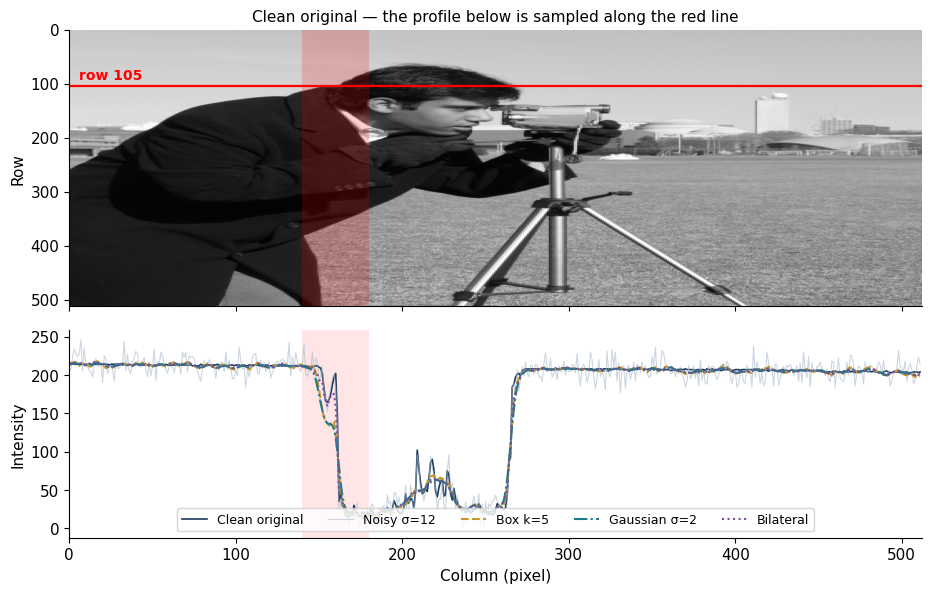

Max gradient in the shaded zone, columns 140–180 (higher = sharper edge preserved):
  Clean        112
  Box           27
  Gaussian      21
  Bilateral     67


In [8]:
# ── Edge preservation test ────────────────────────────────────────────────────
# Extract a row across a strong edge — compare how each filter handles it.
# Pre-written: just run this after completing apply_all_filters.

try:
    row      = 105            # horizontal slice through the image
    z0, z1   = 140, 180       # column range used for the sharpness measurement
    x        = np.arange(cam.shape[1])

    lo_res = apply_all_filters(noisy_lo)
    if any(v is None for v in lo_res.values()):
        raise ValueError

    fig, (axim, ax) = plt.subplots(
        2, 1, figsize=(11, 6.6), height_ratios=[2.0, 1.5],
        sharex=True, gridspec_kw={'hspace': 0.10})

    # ── top: the image, with the sampled row drawn on it ─────────────────────
    # aspect='auto' stretches the image to the full axis width so its columns
    # line up exactly with the profile below (it does distort the aspect ratio)
    axim.imshow(cam, cmap='gray', vmin=0, vmax=255, aspect='auto',
                extent=[0, cam.shape[1], cam.shape[0], 0])
    axim.axhline(row, color='red', lw=1.6)
    axim.axvspan(z0, z1, color='red', alpha=0.18, lw=0)
    axim.text(6, row - 8, f"row {row}", color='red', fontsize=10,
              fontweight='bold', va='bottom')
    axim.set_ylabel("Row")
    axim.set_title("Clean original — the profile below is sampled along the red line",
                   fontsize=11)
    axim.tick_params(labelbottom=False)

    # ── bottom: the intensity profile ────────────────────────────────────────
    ax.plot(x, cam[row],                 lw=1.2, color='#1A3A5C', label='Clean original')
    ax.plot(x, noisy_lo[row],            lw=0.8, color='#AABBCC', label='Noisy σ=12', alpha=0.6)
    ax.plot(x, lo_res['box'][row],       lw=1.5, color='#C8962C', label='Box k=5',      linestyle='--')
    ax.plot(x, lo_res['gaussian'][row],  lw=1.5, color='#1D7A8C', label='Gaussian σ=2', linestyle='-.')
    ax.plot(x, lo_res['bilateral'][row], lw=1.5, color='#7B4EA0', label='Bilateral',    linestyle=':')
    ax.axvspan(z0, z1, color='red', alpha=0.10, lw=0)
    ax.set_xlim(0, cam.shape[1])
    ax.set_xlabel("Column (pixel)")
    ax.set_ylabel("Intensity")
    ax.legend(fontsize=9, ncol=5, loc='lower center')
    plt.show()

    # Measure edge sharpness: max gradient magnitude across the edge zone
    print(f"Max gradient in the shaded zone, columns {z0}–{z1} "
          f"(higher = sharper edge preserved):")
    for name, im in [("Clean", cam), ("Box", lo_res['box']),
                     ("Gaussian", lo_res['gaussian']), ("Bilateral", lo_res['bilateral'])]:
        g = int(np.abs(np.diff(im[row, z0:z1].astype(int))).max())
        print(f"  {name:<12} {g:3d}")

except (TypeError, ValueError, NotImplementedError):
    print("Complete apply_all_filters first.")


### Checkpoint 2

**Q2a.** Look at your PSNR table. At **low noise (σ=12)**, which filter gives the
highest PSNR? Does it also give the best *visual* result?
(PSNR is a global metric — it doesn't know about edges.)

Bilateral filter is the one with a higher PSNR than the rest, which coincides with it being the closer to the original. At plain sight, it is also close to the Gaussian but a bit far away from the box, which just blends some of the noise in bigger, more general clusters, reducing the PSNR level as well. However, when comparing to the higher noise level, bilateral still looks better than the other two filters, although giving a lower PSNR, as it does not discriminate edges and borders.

---

**Q2b.** Look at the edge profile plot. Which filter best preserves the sharp
drop at the head edge? What property of that filter explains why?

Bilateral filter preserves sharp drop better than the other filters, this is mainly due to the weight bilateral filter gives to each neighboring pixel depending on how close they are in color compared to the target pixel, meaning a border or edge will still get values that keep them unblended from one another.

---

**Q2c.** At **high noise (σ=40)**, the gap between the best and worst filter
is larger. Why does noise level amplify the difference between Gaussian and bilateral?

When the sigmaColor gets tuned correctly, there is a larger gap getween Gaussian and bilateral filters because not only closeness but more sensitivity to color is also added to the equation. This causes a simple Gaussian filter to blend more of the noise in the result image compared to the bilateral, that will try to equate the noise levels in areas where the original (unnoised) color is similar.

---

**Q2d.** The `sigmaColor` values above are fixed, they are never retuned for the noise level. Try changing `sigmaColor` in `apply_all_filters` and re-running.

* Set it very low (say 5). What happens to PSNR, and what happens to the noise in flat regions? Is the filter still doing anything?

* Now set it very high (say 300). What happens to PSNR, and how does the result compare to the Gaussian?

* Roughly where does PSNR peak for σ=12? For σ=40? What is that value in relation to the noise level?

Recall that `sigmaColor` controls how much two pixels may differ in brightness and still be averaged together. Large values let almost anything average with anything; small values mean only near-identical pixels contribute.

When the sigmaColorlevels are very low, getting closer to 0 (as the question suggested, with a value of 5), the filter basically blurs everything similar to another types of filters, even performing worse than them. However, when the value is very high, the PSNR is also low, as any noise will be taken into account as a possible edge/border, which will be kept and blurred lightly.
PSNR peaks at around sigmaColor=20 for σ=12 having a value of 31.6 dB, and around sigmaColor=100 for σ=40 with a value of 25.6 dB

---


---
## Part 3 — Preprocessing Real Aerial Imagery  `⏱ ~25 min`


Everything so far has used clean textbook images. This section uses **real
scanned aerial photography of Prince Edward Island** — the same source as your
group project.

Three photographs of **the same 800 m × 800 m patch of ground**, taken 33 years
apart:

| Year | Native resolution | Image size |
|---|---|---|
| 1935 | 0.5 m/px | 1601 × 1601 |
| 1958 | 1.159 m/px | 691 × 691 |
| 1968 | 0.5 m/px | 1601 × 1601 |

Same ground, three different pixel grids and three different exposures. Before
you can compare them you have to fix both problems. That is what preprocessing
*is*.


### Getting the imagery

The three photographs live in the public course repository. The cell below
downloads them into your working directory the first time you run it, and does
nothing on re-runs. About 3 MB.

If you are on Colab, the files land in `/content` and will disappear when the
runtime is recycled — just re-run the cell.


In [39]:
# ── Get the aerial imagery ──────────────────────────────────────────
# Downloads three scanned PEI aerial photographs (~3 MB) into the working
# directory. Safe to re-run — it skips the download once the files are there.
import io, os, urllib.request, zipfile

DATA_URL = ("https://raw.githubusercontent.com/andrewgodbout/MCS-3950"
            "-F26/main/Notebooks/data/AL2.zip")
NEEDED = ["pei_1935.png", "pei_1958.png", "pei_1968.png"]

if all(os.path.exists(f) for f in NEEDED):
    print("Aerial imagery already present — skipping download.")
else:
    print(f"Downloading from {DATA_URL} ...")
    try:
        with urllib.request.urlopen(DATA_URL, timeout=60) as resp:
            blob = resp.read()
    except Exception as e:
        raise RuntimeError(
            f"Could not download the imagery ({type(e).__name__}: {e}).\n"
            f"Open {DATA_URL} in a browser and place the three PNG files "
            f"next to this notebook instead."
        ) from None

    with zipfile.ZipFile(io.BytesIO(blob)) as z:
        members = z.namelist()
        unexpected = [m for m in members if m not in NEEDED]
        if unexpected:
            raise RuntimeError(f"Unexpected files in the archive: {unexpected}")
        z.extractall(".")
    print(f"  {len(blob)/1e6:.1f} MB downloaded and extracted")

missing = [f for f in NEEDED if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(f"Still missing after download: {missing}")

for f in NEEDED:
    print(f"  {f}  {os.path.getsize(f)/1e6:5.2f} MB")


  3.1 MB downloaded and extracted
  pei_1935.png   1.00 MB
  pei_1958.png   0.32 MB
  pei_1968.png   1.77 MB


In [40]:
# ── Helper: show images at sizes proportional to their pixel dimensions ──────
def show_true_scale(images, titles, cmap='gray', vmin=0, vmax=255, figw=16):
    """
    Like show(), but each panel is sized in proportion to the image's pixel
    dimensions — so a smaller array actually looks smaller. Use this when the
    point is that the images are on *different* grids.
    """
    widths  = [im.shape[1] for im in images]
    tallest = max(im.shape[0] for im in images)

    fig, axes = plt.subplots(
        1, len(images),
        figsize=(figw, figw * tallest / sum(widths)),
        gridspec_kw={'width_ratios': widths})
    if len(images) == 1:
        axes = [axes]

    for ax, im, t in zip(axes, images, titles):
        ax.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.set_aspect('equal')     # one pixel is square
        ax.set_anchor('N')         # hang the panels from a common top edge
        ax.set_title(t, fontsize=11)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

1935:  1601 x 1601 px   0.500 m/px   = 800 m across   mean=133.3  std=40.8
1958:   691 x 691  px   1.159 m/px   = 801 m across   mean=154.0  std=41.1
1968:  1601 x 1601 px   0.500 m/px   = 800 m across   mean=161.8  std=29.8


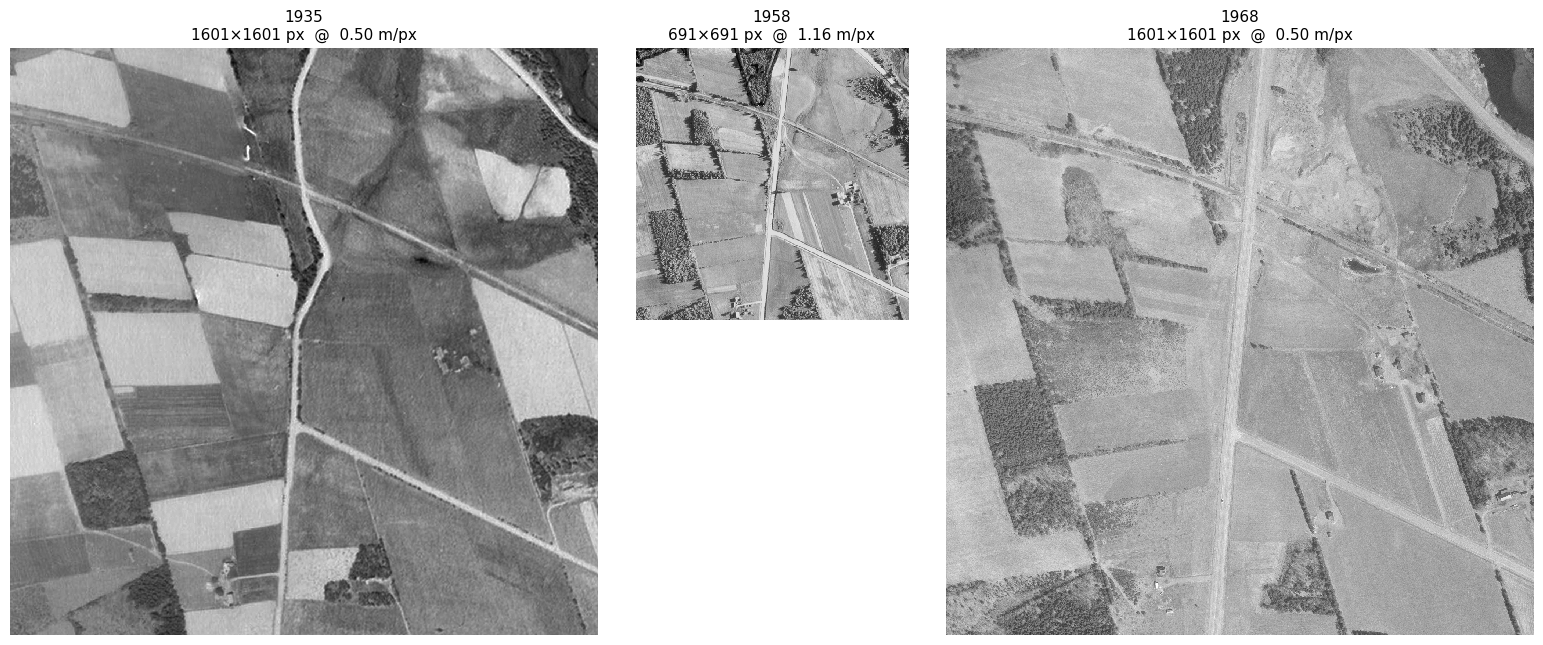

In [41]:
# ── Load the three epochs ─────────────────────────────────────────────────────
# Files: pei_1935.png, pei_1958.png, pei_1968.png
from PIL import Image

RES = {1935: 0.5, 1958: 1.1593543264609192, 1968: 0.5}   # metres per pixel
YEARS = [1935, 1958, 1968]

aerial = {y: np.array(Image.open(f'pei_{y}.png')) for y in YEARS}

for y in YEARS:
    a = aerial[y]
    print(f"{y}:  {a.shape[1]:>4} x {a.shape[0]:<4} px   "
          f"{RES[y]:.3f} m/px   = {a.shape[1]*RES[y]:.0f} m across   "
          f"mean={a.mean():5.1f}  std={a.std():4.1f}")

show_true_scale(
    [aerial[y] for y in YEARS],
    [f"{y}\n{aerial[y].shape[1]}×{aerial[y].shape[0]} px  @  {RES[y]:.2f} m/px"
     for y in YEARS],
    figw=16)

Two problems should be obvious immediately.

**Different pixel grids.** Pixel (100, 100) is a different place on the ground in
each image. You cannot subtract these arrays — they aren't even the same shape.

**Different exposures.** Look at the standard deviations. 1968 is visibly flatter
than the others. Subtracting raw images would mostly measure *how the film was
developed*, not how the landscape changed.


### 3.1 — Put them on a common grid

Resample all three to **1.0 m/px**, the same convention your project data uses.
At 1 m/px one pixel is one square metre, so a pixel count is an area in m².

Going 0.5 m → 1.0 m is **downsampling** and needs anti-aliasing.
Going 1.159 m → 1.0 m is a slight **upsample**.


1935: (1601, 1601) -> (800, 800)
1958: (691, 691) -> (800, 800)
1968: (1601, 1601) -> (800, 800)

all three now 800 x 800 px, 1 m/px, same ground


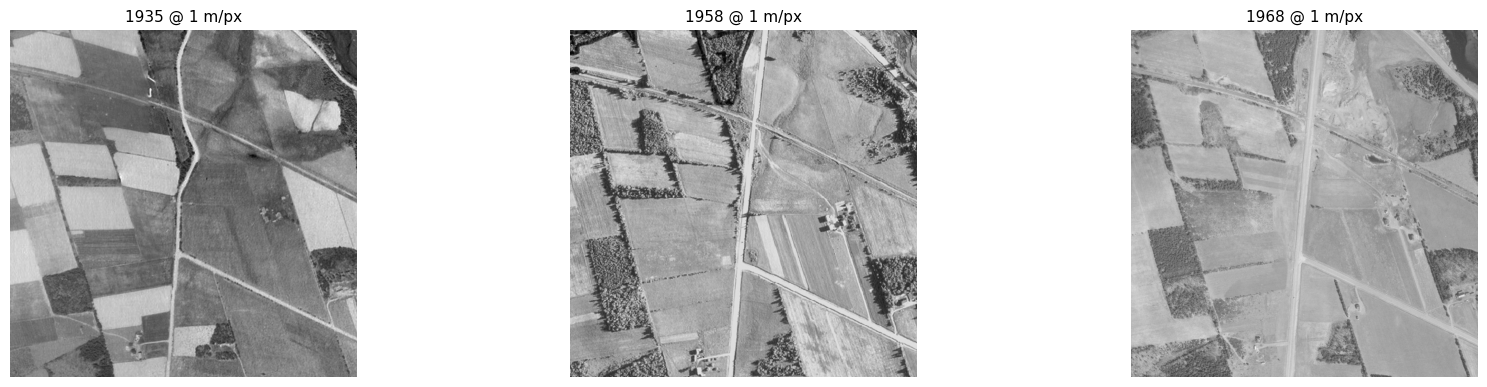

In [42]:
TARGET_RES = 1.0
SIZE = 800          # 800 m at 1 m/px

def to_common_grid(img, src_res, target_res=TARGET_RES, interp=None):
    """Resample an image from src_res to target_res metres/pixel."""
    scale  = src_res / target_res
    new_wh = (int(round(img.shape[1]*scale)), int(round(img.shape[0]*scale)))
    if interp is None:
        interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    return cv2.resize(img, new_wh, interpolation=interp)

grid = {y: to_common_grid(aerial[y], RES[y]) for y in YEARS}

# Real data rarely divides evenly: 1958 lands on 801 px, the others on 800.
# Crop everything to a common size so the arrays are directly comparable.
side = min(min(g.shape) for g in grid.values())
grid = {y: g[:side, :side] for y, g in grid.items()}

for y in YEARS:
    print(f"{y}: {aerial[y].shape} -> {grid[y].shape}")
print(f"\nall three now {side} x {side} px, 1 m/px, same ground")

show([grid[y] for y in YEARS], [f"{y} @ 1 m/px" for y in YEARS], figw=18)


**Why the interpolation choice matters.** Compare a correct anti-aliased
downsample against a naive nearest-neighbour one on the 1968 image, which has
fine field texture and a straight rail line — exactly the content that aliases.


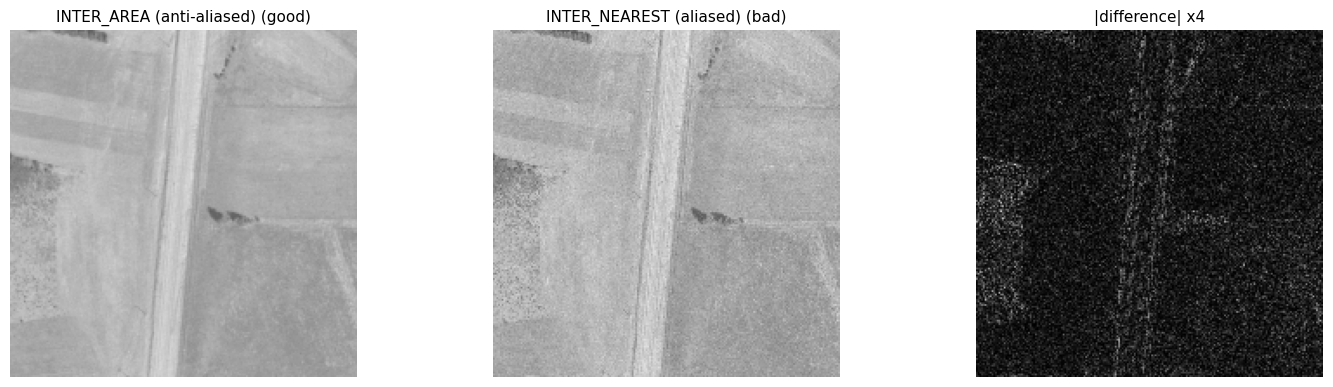

mean |difference| over the whole image: 8.23 grey levels


In [43]:
good = to_common_grid(aerial[1968], 0.5, 1.0, cv2.INTER_AREA)     # anti-aliased
bad  = to_common_grid(aerial[1968], 0.5, 1.0, cv2.INTER_NEAREST)  # aliased

# zoom on a 200 m detail so the difference is visible
z = slice(300, 500)
show([good[z, z], bad[z, z], cv2.absdiff(good, bad)[z, z] * 4],
     ["INTER_AREA (anti-aliased) (good)", "INTER_NEAREST (aliased) (bad)",
      "|difference| x4"], figw=15)

print(f"mean |difference| over the whole image: {cv2.absdiff(good,bad).mean():.2f} grey levels")


### 3.2 — Radiometric normalisation

The images are now aligned on a common grid, but still have different tone.
Plot the histograms and the problem is obvious.


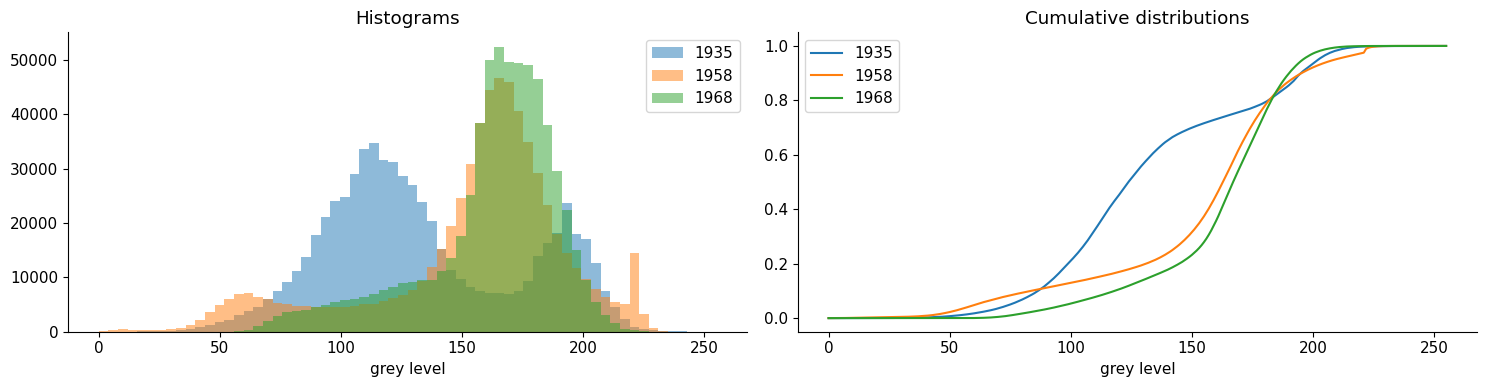

  year    mean     std    1%   50%   99%
  1935   133.3    40.7    54   124   213
  1958   154.1    41.1    42   163   222
  1968   161.8    28.3    76   168   207


In [44]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
for y in YEARS:
    ax[0].hist(grid[y].ravel(), bins=64, range=(0,255), alpha=0.5, label=str(y))
    ax[1].plot(np.cumsum(np.histogram(grid[y], bins=256, range=(0,255))[0]) /
               grid[y].size, label=str(y))
ax[0].set_title("Histograms"); ax[0].set_xlabel("grey level"); ax[0].legend()
ax[1].set_title("Cumulative distributions"); ax[1].set_xlabel("grey level"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"{'year':>6} {'mean':>7} {'std':>7} {'1%':>5} {'50%':>5} {'99%':>5}")
for y in YEARS:
    q = np.percentile(grid[y], [1, 50, 99])
    print(f"{y:>6} {grid[y].mean():7.1f} {grid[y].std():7.1f}"
          f" {q[0]:5.0f} {q[1]:5.0f} {q[2]:5.0f}")


**Histogram matching** reshapes one image's intensity distribution to match another's. Implement it below — it is pure lookup-table work, no convolution.

The cumulative distribution above gives, for each grey level, the total count of pixels at or below that level. It answers: for a pixel of brightness L, what fraction of the image is darker? A CDF value of 0.80 means that pixel is brighter than 80% of the image — the 80th percentile.

*Note: Each index position in the cdf represents that grey level i.e., at index position zero we store the CDF for pixels equal to zero grey value (black), at index position 255 we store the CDF for pixels equal to grey value 255 (white).

Percentile rank is the quantity we can compare across images, even when their exposures differ. So we keep each pixel's rank and rewrite its grey value: look up the source pixel's CDF value, find the grey level that sits at that same CDF value in the reference, and use it.

The recipe:

1. Compute the cumulative distribution function (CDF) of the source and of the reference.
   * The plots above already build these from the histograms.

    * To normalise to [0, 1], divide by the total pixel count — `src.size`, or equivalently `cdf[-1`], the final entry of the cumulative sum.

2. For each grey level `v` in the source, find the first reference level whose CDF reaches `CDF_source(v)`.

  * `np.searchsorted` does this. Pass it the whole source CDF array and it returns all 256 answers at once, so you don't need a Python loop.

  * `np.searchsorted` returns an array (with 256 elements) (*note `int64` is the type that `searchsorted` returns so cast to `uint8`)*

3. Apply that mapping as a 256-entry lookup table.
     * The table takes a grey value from the source and tells you the grey value it should become.

Each pixel's rank is preserved — the brightest pixel stays the brightest — but the grey values are rewritten so the source ends up with the reference's distribution.

We use 1958 as the reference. 1958 and 1935 have nearly identical spread (std 41.2 and 40.7); 1968 is much flatter at 28.3. Matching onto 1968 would compress the other two epochs and throw away contrast we cannot get back.

In [58]:
def match_histogram(src, ref):
    """Remap src so its intensity distribution matches ref.

    src, ref : uint8 grayscale arrays (need not be the same shape)
    returns  : uint8 array, same shape as src
    """
    # ── Step 1: cumulative distributions, normalised to [0, 1] ────────────────

    counts = np.histogram(x, bins=256, range=(0,255))[0]

    cdf = np.cumsum(counts) / counts.sum()

    src_cdf = counts   # YOUR CODE HERE

    ref_cdf = cdf   # YOUR CODE HERE

    #   hint: np.histogram(x, bins=256, range=(0,255))[0]  -> counts
    #         np.cumsum(counts) / counts.sum()             -> CDF

    if src_cdf is None or ref_cdf is None:
        raise NotImplementedError("Fill in Step 1 (the two CDFs).")

    # ── Step 2: build the 256-entry lookup table ─────────────────────────────
    #   for each level v, find the ref level whose CDF first reaches src_cdf[v]
    #   hint: np.searchsorted(ref_cdf, src_cdf) gives those indices directly

    #don't forget to convert to uint8

    lut = np.uint8(np.searchsorted(ref_cdf, src_cdf))       # YOUR CODE HERE  -> np.uint8 array of length 256

    if lut is None:
        raise NotImplementedError("Fill in Step 2 (the lookup table).")

    # ── Step 3: apply ────────────────────────────────────────────────────────
    # this is a fancy indexing trick that will do the lookups for all the
    #values that are passed in the array argument (src) (equivalent in concept to loops iterating over all the pixels.)
    return lut[src]


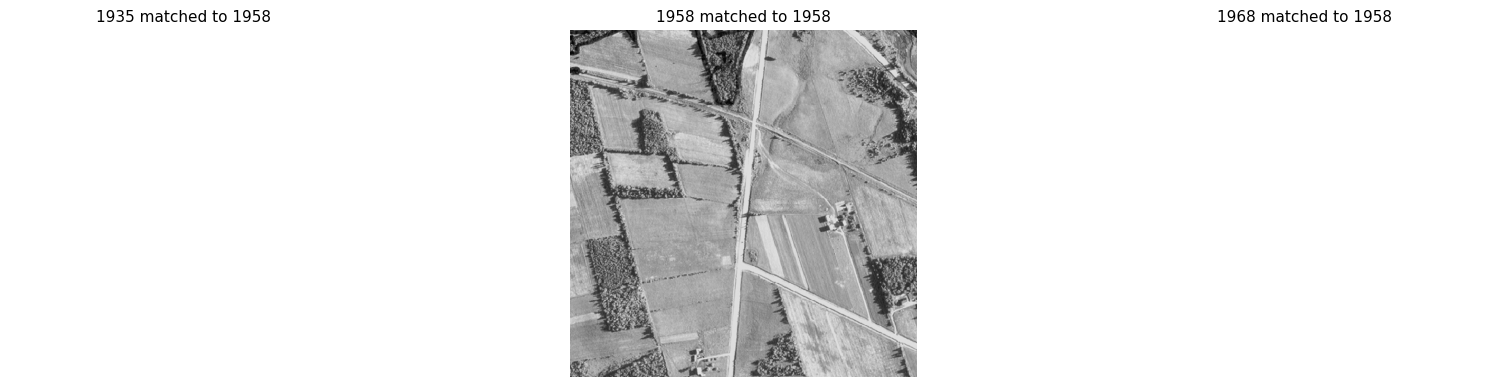

  year      before (mean/std)       after (mean/std)
  1935      133.3 / 40.7          255.0 / 0.0     
  1958      154.1 / 41.1          154.1 / 41.1    
  1968      161.8 / 28.3          255.0 / 0.0     


In [59]:
# ── Match 1935 and 1968 onto the 1958 reference ───────────────────────────────
try:
    REF = 1958
    matched = {y: (grid[y] if y == REF else match_histogram(grid[y], grid[REF]))
               for y in YEARS}

    show([matched[y] for y in YEARS], [f"{y} matched to {REF}" for y in YEARS], figw=18)

    print(f"{'year':>6}   {'before (mean/std)':>20}   {'after (mean/std)':>20}")
    for y in YEARS:
        print(f"{y:>6}   {grid[y].mean():8.1f} / {grid[y].std():<8.1f}   "
              f"{matched[y].mean():8.1f} / {matched[y].std():<8.1f}")

except (TypeError, ValueError, NotImplementedError) as e:
    print(f"Complete match_histogram first: {e}")


### 3.3 — Does it actually help?

The test that matters: does normalisation make a **change map** more meaningful?


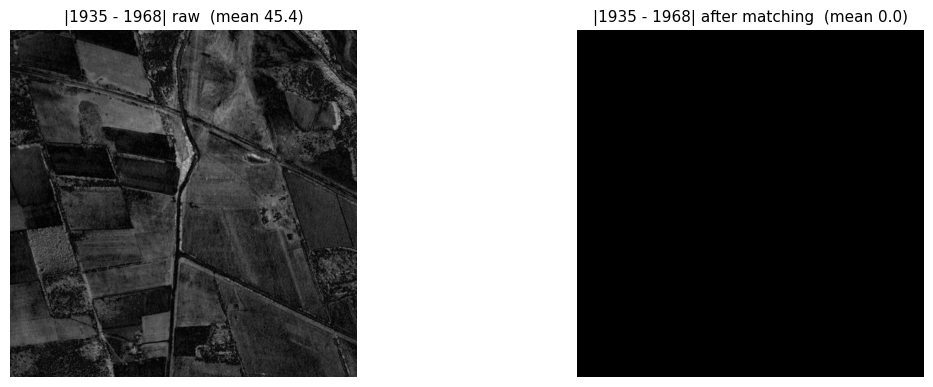

raw difference     : mean  45.42   std  27.49
matched difference : mean   0.00   std   0.00

A lower mean difference means less of the signal is pure exposure mismatch.
What remains should be actual landscape change — field boundaries,
buildings, tree lines that appeared or disappeared between 1935 and 1968.


In [49]:
try:
    raw_diff     = cv2.absdiff(grid[1935],    grid[1968])
    matched_diff = cv2.absdiff(matched[1935], matched[1968])

    show([raw_diff, matched_diff],
         [f"|1935 - 1968| raw  (mean {raw_diff.mean():.1f})",
          f"|1935 - 1968| after matching  (mean {matched_diff.mean():.1f})"],
         figw=13)

    print(f"raw difference     : mean {raw_diff.mean():6.2f}   std {raw_diff.std():6.2f}")
    print(f"matched difference : mean {matched_diff.mean():6.2f}   std {matched_diff.std():6.2f}")
    print()
    print("A lower mean difference means less of the signal is pure exposure mismatch.")
    print("What remains should be actual landscape change — field boundaries,")
    print("buildings, tree lines that appeared or disappeared between 1935 and 1968.")
except (TypeError, ValueError, NameError, NotImplementedError) as e:
    print(f"Complete match_histogram first: {e}")


### 3.4 — Denoising real film grain

The noise here is **real** — film grain, dust and scanner noise, not something we
added. Work on a 400 m crop so the filters stay fast.

To compare filters honestly we need two separate measurements:

- **Grain** — the standard deviation inside a *flat* patch (a bare field), where
  any variation is noise rather than structure.
- **Edge strength** — the 99th percentile of gradient magnitude, which reflects
  the genuinely sharp boundaries we want to keep.

Averaging the gradient over the whole image would mix these up: removing grain
lowers the average gradient, making a good filter look bad.


In [ ]:
crop = grid[1935][200:600, 200:600]          # 400 x 400 m at 1 m/px

# Find the flattest 40x40 patch — a bare field, so its variation is pure grain
flat = min(((crop[y:y+40, x:x+40].std(), x, y)
            for y in range(0, 360, 20) for x in range(0, 360, 20)))
grain_std, fx, fy = flat
print(f"flattest patch at ({fx},{fy}): std = {grain_std:.2f}  <- grain amplitude")

def quality(a):
    """Return (grain, edge_strength) for an image."""
    grain = a[fy:fy+40, fx:fx+40].std()
    gx = cv2.Sobel(a, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(a, cv2.CV_64F, 0, 1, ksize=3)
    return grain, np.percentile(np.hypot(gx, gy), 99)

n0, e0 = quality(crop)

gauss = cv2.GaussianBlur(crop, (0,0), sigmaX=1.5)
bilat = cv2.bilateralFilter(crop, d=7, sigmaColor=20, sigmaSpace=7)

show([crop, gauss, bilat],
     ["Original (real grain)", "Gaussian sigma=1.5", "Bilateral d=7, sigmaColor=20"],
     figw=15)

print(f"\n{'filter':<32} {'grain':>7} {'edge':>8} {'grain kept':>11} {'edge kept':>10}")
print(f"{'original':<32} {n0:7.2f} {e0:8.1f} {'100%':>11} {'100%':>10}")
for name, a in (("Gaussian sigma=1.5", gauss), ("Bilateral d=7 sColor=20", bilat)):
    n, e = quality(a)
    print(f"{name:<32} {n:7.2f} {e:8.1f} {100*n/n0:10.0f}% {100*e/e0:9.0f}%")


Both filters remove roughly the same amount of grain — but one keeps its edges
and the other doesn't. That is the whole argument for bilateral filtering before
segmentation.

**But bilateral only works if you tune it.** `sigmaColor` controls how large an
intensity difference the filter still treats as "the same region". Set it much
larger than the grain amplitude and the filter stops distinguishing noise from
edges — it degenerates into an expensive Gaussian.


In [ ]:
too_wide = cv2.bilateralFilter(crop, d=9, sigmaColor=50, sigmaSpace=9)
n, e = quality(too_wide)
print(f"grain amplitude in this image: {n0:.2f}")
print()
print(f"{'setting':<32} {'grain kept':>11} {'edge kept':>10}")
for name, a in (("bilateral sigmaColor=20", bilat), ("bilateral sigmaColor=50", too_wide)):
    nn, ee = quality(a)
    print(f"{name:<32} {100*nn/n0:10.0f}% {100*ee/e0:9.0f}%")
print()
print("Rule of thumb: sigmaColor should be a small multiple of the noise")
print("amplitude, NOT a large number chosen arbitrarily.")

show([crop, bilat, too_wide],
     ["Original", "sigmaColor=20 (edges kept)", "sigmaColor=50 (edges lost)"], figw=15)


### Checkpoint 3

**Q3a.** In 3.1, the mean absolute difference between `INTER_AREA` and
`INTER_NEAREST` is only a couple of grey levels — yet the zoomed crops look
clearly different. Why is a small average difference still a problem for
measuring field boundaries?

*Your answer:*

---

**Q3b.** Histogram matching made the 1935↔1968 difference image smaller.
Does a smaller difference always mean a *better* result? Describe a case where
histogram matching would destroy real signal you wanted to keep.

*Hint: Remember that many years separate the images*

*Your answer:*

---

**Q3c.** Compute the mean intensity value (brightness) of each quadrant of the matched 1935 image:

```python
h, w = matched[1935].shape
for name, q in (("TL", matched[1935][:h//2,:w//2]), ("TR", matched[1935][:h//2,w//2:]),
                ("BL", matched[1935][h//2:,:w//2]), ("BR", matched[1935][h//2:,w//2:])):
    print(name, round(q.mean(), 1))
```

Global histogram matching fixed the difference *between* images. Did it fix
the tonal variation *within* one image? What kind of method would?

*Note: images may not be uniformly exposed. The angle of the sun, vignetting, uneven development, scanner illumination are a few of the impactful mechansisms in the image chain that may cause an image to have bright corners or areas of different exposure level (like the 1935 image).*

*Your answer:*


---
## ★ Bonus — Mystery Kernel Challenge


Five filters were applied to the coins image. Figure out **which kernel**
produced each output — **without running the filter** — by reasoning about
the kernel weights.

Write your guesses in the answer cell, then run the reveal cell to check.


In [ ]:
# ── Mystery outputs ───────────────────────────────────────────────────────────
mystery = {
    "K1": np.array([[-1,-1,-1],[-1, 8,-1],[-1,-1,-1]], dtype=np.float32),
    "K2": np.ones((15,15), dtype=np.float32) / 225.0,
    "K3": np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32),
    "K4": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32),
    "K5": cv2.getGaussianKernel(9, 2) @ cv2.getGaussianKernel(9, 2).T,
}

# Scrambled order for display
_display_order = ["K3", "K1", "K5", "K2", "K4"]
outputs = {}
for key in _display_order:
    raw = cv2.filter2D(coins, cv2.CV_32F, mystery[key])
    disp = np.clip(np.abs(raw) if raw.min() < 0 else raw, 0, 255).astype(np.uint8)
    outputs[key] = disp

fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
axes[0].imshow(coins, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis('off')
for ax, key, num in zip(axes[1:], _display_order, range(1,6)):
    ax.imshow(outputs[key], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"Output {num}")
    ax.axis('off')
plt.tight_layout()
plt.show()

print("Kernels (not in output order):")
for key, k in mystery.items():
    flat = k.ravel()
    desc = f"shape={k.shape}  sum={k.sum():+.2f}  min={flat.min():+.2f}  max={flat.max():+.2f}"
    print(f"  {key}: {desc}")


In [ ]:
# ── Your guesses ─────────────────────────────────────────────────────────────
# Edit: output_number → kernel label (K1–K5)
guesses = {
    1: '?',
    2: '?',
    3: '?',
    4: '?',
    5: '?',
}

# ── Reveal ────────────────────────────────────────────────────────────────────
answers = {num+1: key for num, key in enumerate(_display_order)}  # output → kernel

if '?' in guesses.values():
    print("Fill in your guesses first.")
else:
    score = 0
    for n in range(1, 6):
        g = guesses[n].upper()
        a = answers[n]
        ok = g == a
        score += ok
        desc = {
            "K1": "Laplacian-like (sum=0, detects edges in all directions)",
            "K2": "Box blur 15×15 (large, heavy blur)",
            "K3": "Sobel X (detects left-to-right intensity change)",
            "K4": "Sharpen (sum=1, boosts centre, subtracts 4-connected neighbours)",
            "K5": "Gaussian σ=2 (smooth, positive-only weights)",
        }
        symbol = "✓" if ok else "✗"
        print(f"Output {n}: {symbol}  Correct: {a}  — {desc[a]}")
    print(f"\nScore: {score}/5")


---
## Reflection — End of Lab


Answer these in the cells below before leaving. They're good practice for Test 1.

---

**R1.** A kernel has weights `[[-1,-2,-1],[0,0,0],[1,2,1]]`.
Without running any code, describe what this filter detects and why.
Is the output image likely to be mostly dark or mostly bright?

*Your answer:*

---

**R2.** You are preprocessing PEI aerial photos from 1935 (very grainy, low
contrast, grayscale). List the steps of your pipeline **in order**, naming
the specific OpenCV function and key parameters for each step.

*Your answer:*

---

**R3.** A teammate suggests: "let's apply the sharpening filter first, then
denoise, so we don't blur the edges we just sharpened." Is this a good idea?
Use the concept of **noise amplification** to explain your answer.

*Your answer:*
